In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


In [4]:
df = pd.read_csv('/kaggle/input/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv')



In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

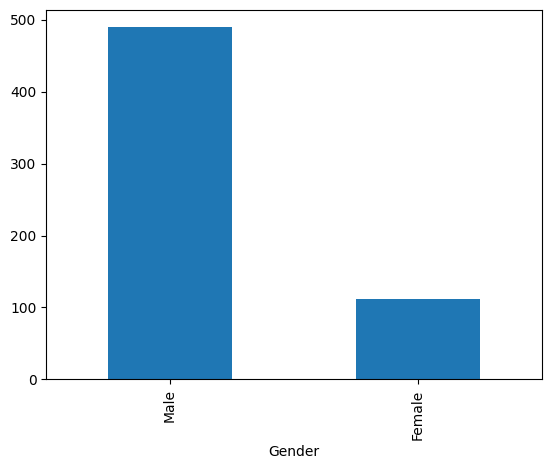

In [14]:
# This is a categorical column
df['Gender'].value_counts().plot(kind = "bar")
x = df[['Gender']]

# Male is dominating female

from sklearn.impute import SimpleImputer
si  = SimpleImputer(strategy = "most_frequent")
x = si.fit_transform(x)

In [24]:
new =pd.DataFrame(x , columns =["fill_male"])


In [26]:
df = pd.concat([df , new] , axis = 1)

<Axes: xlabel='Gender', ylabel='count'>

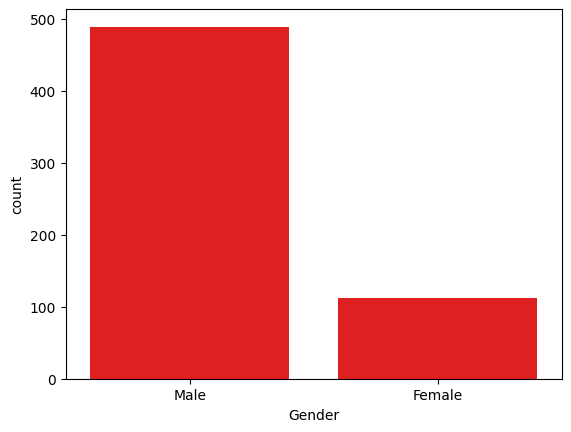

In [37]:
import seaborn as sns
sns.countplot(x=df['Gender'] , color = 'red')

In [48]:
(df.isnull().sum() / df.shape[0])*100

new_df = df.dropna(subset = ['Married'] )

In [53]:
new_df['Married'].value_counts() / len(new_df)

Married
Yes    0.651391
No     0.348609
Name: count, dtype: float64

In [54]:
df['Married'].value_counts() / len(df)

Married
Yes    0.648208
No     0.346906
Name: count, dtype: float64

In [ ]:
new_df.isnull().sum()